# Emotions per topic — significance testing

Compares outlet anger scores against the Tagesschau baseline per topic cluster using Mann-Whitney U tests with Benjamini-Hochberg FDR correction.

## 1  Load & merge

Load emotion scores and topic assignments, merge on `row_id`.

In [11]:
import pandas as pd
from pathlib import Path

root = Path.cwd()
if root.name == "04_SentimentAnalysis":
    root = root.parent

df = pd.read_csv(root / "04_SentimentAnalysis/outputs/emotion_fulltext_with_topiclabels.csv")


df = df.rename(columns={"Manual Cluster Label": "topic", "emotion_anger": "anger", "emotion_fear":"fear"})
df["anger"] = pd.to_numeric(df["anger"], errors="coerce")
df["fear"]  = pd.to_numeric(df["fear"], errors="coerce")
df = df.dropna(subset=["anger", "fear", "topic", "source"])


## 2  Pairwise Mann-Whitney U + BH correction

For each *(topic, outlet)* pair with n ≥ 30 on both sides, run a two-sided Mann-Whitney U test and compute rank-biserial effect size r. Apply BH FDR correction across all valid pairs.

In [12]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

REFERENCE   = "Tagesschau"
EFFECT_R_MIN = 0.10   # minimum |r| required to report a significant marker
ALT_OUTLETS = [o for o in df["source"].unique() if o != REFERENCE]
MIN_N       = 20

records  = []
excluded = []

for topic in df["topic"].unique():
    df_t    = df[df["topic"] == topic]
    ts_vals = df_t.loc[df_t["source"] == REFERENCE, "anger"].values

    for outlet in ALT_OUTLETS:
        alt_vals = df_t.loc[df_t["source"] == outlet, "anger"].values

        if len(alt_vals) < MIN_N or len(ts_vals) < MIN_N:
            excluded.append({"topic": topic, "outlet": outlet,
                             "n_outlet": len(alt_vals), "n_tagesschau": len(ts_vals),
                             "reason": f"n < {MIN_N}"})
            continue

        U, p_raw = mannwhitneyu(alt_vals, ts_vals, alternative="two-sided")
        n1, n2   = len(alt_vals), len(ts_vals)
        r        = (2 * U) / (n1 * n2) - 1   # positive = alt outlet angrier than Tagesschau

        records.append({
            "topic":                topic,
            "outlet":               outlet,
            "n_outlet":             n1,
            "n_tagesschau":         n2,
            "mean_anger_outlet":    float(np.mean(alt_vals)),
            "mean_anger_tagesschau": float(np.mean(ts_vals)),
            "U_statistic":          U,
            "p_raw":                p_raw,
            "effect_size_r":        r,
        })

results = pd.DataFrame(records)

reject, p_adj, _, _ = multipletests(results["p_raw"].values, alpha=0.05, method="fdr_bh")
results["p_adjusted"]  = p_adj
results["significant"] = reject & (results["effect_size_r"].abs() >= EFFECT_R_MIN)

# Masked p-value: cells that don't meet the effect size floor are treated as non-significant
results["p_adj_masked"] = results["p_adjusted"].where(
    results["effect_size_r"].abs() >= EFFECT_R_MIN, other=1.0
)

results = results.sort_values("p_adjusted").reset_index(drop=True)
results


,topic,outlet,n_outlet,n_tagesschau,mean_anger_outlet,mean_anger_tagesschau,U_statistic,p_raw,effect_size_r,p_adjusted,significant,p_adj_masked
0,Social Policy & Welfare,Tichys_Einblick,260,471,0.869515,0.659799,104809.0,3.112432e-57,0.711726,2.863438e-55,True,2.863438e-55
1,German Party Politics,Tichys_Einblick,436,388,0.864916,0.676051,138326.0,6.006017e-56,0.635368,2.762768e-54,True,2.762768e-54
2,German Economy & Industry,Tichys_Einblick,222,597,0.841044,0.657513,108932.0,1.270280e-45,0.643835,3.895526e-44,True,3.895526e-44
3,"Energy, Climate & Environment",Tichys_Einblick,162,461,0.848386,0.675471,62324.0,7.902185e-37,0.669050,1.817503e-35,True,1.817503e-35
4,Miscellaneous,Tichys_Einblick,212,612,0.782626,0.577318,102207.0,7.410364e-36,0.575518,1.363507e-34,True,1.363507e-34
...,...,...,...,...,...,...,...,...,...,...,...,...
87,US & Transatlantic Politics,Antispiegel,52,655,0.737026,0.733886,17746.0,6.137467e-01,0.042043,6.416443e-01,False,1.000000e+00
88,Russia (-Ukraine) Diplomacy & Sanctions,RT_de,1089,400,0.612221,0.612843,220570.0,7.064873e-01,0.012718,7.303014e-01,False,1.000000e+00
89,Russia (-Ukraine) Diplomacy & Sanctions,Nius,66,400,0.602571,0.612843,13464.0,7.948926e-01,0.020000,8.125569e-01,False,1.000000e+00
90,Russia-Ukraine War,Nius,30,299,0.685481,0.682301,4549.0,8.982653e-01,0.014270,9.081363e-01,False,1.000000e+00


## 3  Heatmaps

**Heatmap 1** — mean anger per topic × outlet; color scale centered on the outlet macro-mean; cells with n < 30 greyed out; `*`/`**` mark BH-significant pairs.

**Heatmap 2** — rank-biserial r per topic × alternative outlet; diverging scale centered at 0.

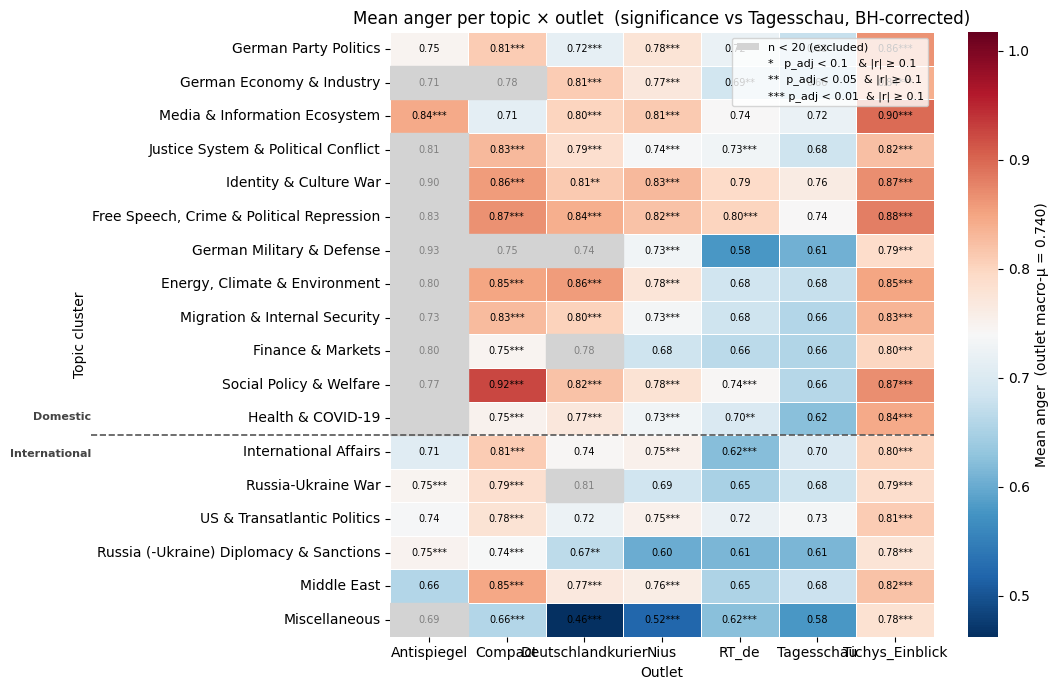

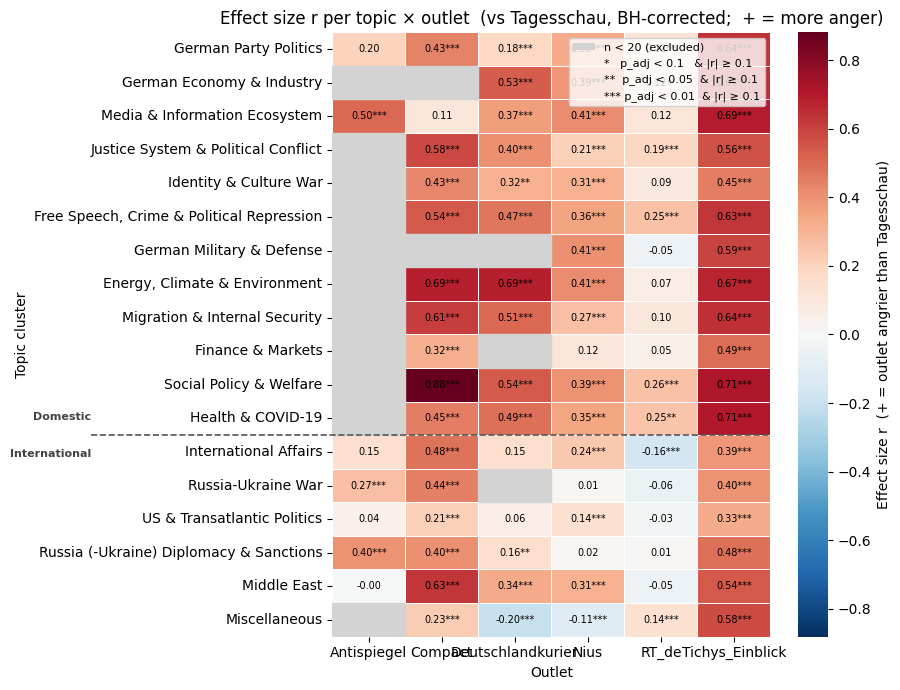

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

ANGER_COL  = "anger"
macro_mean = float(df.groupby("source")[ANGER_COL].mean().mean())

def _sig_marker(p_adj):
    if p_adj < 0.01: return "***"
    if p_adj < 0.05: return "**"
    if p_adj < 0.1: return "*"
    return ""

# ── Sort topics: Domestic → International → Other ────────────────────────────
_DOMESTIC = {
    "Social Policy & Welfare", "Health & COVID-19", "Energy, Climate & Environment",
    "German Economy & Industry", "Migration & Internal Security", "German Party Politics",
    "Free Speech, Crime & Political Repression", "Media & Information Ecosystem",
    "Justice System & Political Conflict", "Identity & Culture War",
    "Finance & Markets", "German Military & Defense", "Green Politics & Woke Culture",
}
_INTERNATIONAL = {
    "Middle East", "Russia (-Ukraine) Diplomacy & Sanctions",
    "US & Transatlantic Politics", "Russia-Ukraine War", "International Affairs",
}
def _geo_rank(t):
    if t in _DOMESTIC:      return 0
    if t in _INTERNATIONAL: return 1
    return 2

topics = sorted(df["topic"].dropna().unique(), key=_geo_rank)

def _add_geo_brackets(ax, topics_ordered):
    """Draw a horizontal separator line between the last Domestic and first International row."""
    last_dom = None
    first_intl = None
    for i, t in enumerate(topics_ordered):
        if t in _DOMESTIC:
            last_dom = i
        elif t in _INTERNATIONAL and first_intl is None:
            first_intl = i
    if last_dom is None or first_intl is None:
        return
    sep_y = first_intl   # exact boundary between last domestic and first international row
    ax.plot([-0.55, 1.0], [sep_y, sep_y], color="#555555", linewidth=1.2,
            linestyle="--", zorder=4, transform=ax.get_yaxis_transform(), clip_on=False)
    ax.text(-0.55, sep_y - 0.4, "Domestic",
            ha="right", va="bottom", fontsize=8, color="#444444", fontweight="bold",
            transform=ax.get_yaxis_transform(), clip_on=False)
    ax.text(-0.55, sep_y + 0.4, "International",
            ha="right", va="top", fontsize=8, color="#444444", fontweight="bold",
            transform=ax.get_yaxis_transform(), clip_on=False)

# ── Build pivots ──────────────────────────────────────────────────────────────
all_outlets = sorted(df["source"].unique())

mean_pivot = (
    df.groupby(["topic", "source"])[ANGER_COL]
    .mean()
    .unstack("source")
    .reindex(index=topics, columns=all_outlets)
)

sig_lookup = (
    results
    .set_index(["topic", "outlet"])["p_adj_masked"]
    .to_dict()
)

n_pivot = (
    df.groupby(["topic", "source"])["anger"]
    .count()
    .unstack("source")
    .reindex(index=topics, columns=all_outlets)
    .fillna(0)
)
ts_n = n_pivot.get(REFERENCE, pd.Series(0, index=topics))

grey_mask = pd.DataFrame(False, index=topics, columns=all_outlets)
for col in all_outlets:
    if col == REFERENCE:
        grey_mask[col] = n_pivot[col] < MIN_N
    else:
        grey_mask[col] = (n_pivot[col] < MIN_N) | (ts_n < MIN_N)

vals   = mean_pivot.to_numpy(dtype=float)
spread = max(float(np.nanmax(np.abs(vals - macro_mean))), 1e-6)
vmin, vmax = macro_mean - spread, macro_mean + spread

legend_patches = [
    mpatches.Patch(facecolor="lightgrey", label=f"n < {MIN_N} (excluded)"),
    plt.Line2D([0], [0], color="none", label=f"*   p_adj < 0.1   & |r| \u2265 {EFFECT_R_MIN}"),
    plt.Line2D([0], [0], color="none", label=f"**  p_adj < 0.05  & |r| \u2265 {EFFECT_R_MIN}"),
    plt.Line2D([0], [0], color="none", label=f"*** p_adj < 0.01  & |r| \u2265 {EFFECT_R_MIN}"),
]

# ── Heatmap 1: mean anger ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(12, 0.9 * len(all_outlets)),
                                max(7,  0.38 * len(topics))))

sns.heatmap(mean_pivot, ax=ax, annot=False,
            cmap="RdBu_r", center=macro_mean, vmin=vmin, vmax=vmax,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": f"Mean anger  (outlet macro-μ = {macro_mean:.3f})"})

for ri, topic in enumerate(topics):
    for ci, outlet in enumerate(all_outlets):
        val    = mean_pivot.at[topic, outlet]
        marker = _sig_marker(sig_lookup.get((topic, outlet), 1.0)) if outlet != REFERENCE else ""
        if grey_mask.at[topic, outlet]:
            ax.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
            if not np.isnan(val):
                ax.text(ci+0.5, ri+0.5, f"{val:.2f}", ha="center", va="center",
                        fontsize=7, color="grey", zorder=3)
        else:
            ax.text(ci+0.5, ri+0.5, f"{val:.2f}{marker}" if not np.isnan(val) else "",
                    ha="center", va="center", fontsize=7, color="black", zorder=3)

ax.legend(handles=legend_patches, loc="upper right", fontsize=8, frameon=True)
ax.set_title("Mean anger per topic × outlet  (significance vs Tagesschau, BH-corrected)")
ax.set_xlabel("Outlet")
ax.set_ylabel("Topic cluster")
_add_geo_brackets(ax, topics)
plt.tight_layout()
plt.show()

# ── Heatmap 2: effect size r ─────────────────────────────────────────────────
r_pivot  = results.set_index(["topic", "outlet"])["effect_size_r"].unstack("outlet")
r_pivot  = r_pivot.reindex(index=[t for t in topics if t in r_pivot.index])
r_topics = r_pivot.index.tolist()
r_outlets= r_pivot.columns.tolist()

grey_r = pd.DataFrame(False, index=r_topics, columns=r_outlets)
for rec in excluded:
    t, o = rec["topic"], rec["outlet"]
    if t in grey_r.index and o in grey_r.columns:
        grey_r.at[t, o] = True

r_spread = max(float(np.nanmax(np.abs(r_pivot.to_numpy(dtype=float)))), 1e-6)

fig2, ax2 = plt.subplots(figsize=(max(10, 0.9 * len(r_outlets)),
                                  max(7,  0.38 * len(r_topics))))

sns.heatmap(r_pivot, ax=ax2, annot=False,
            cmap="RdBu_r", center=0, vmin=-r_spread, vmax=r_spread,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Effect size r  (+ = outlet angrier than Tagesschau)"})

for ri, topic in enumerate(r_topics):
    for ci, outlet in enumerate(r_outlets):
        val    = r_pivot.at[topic, outlet] if topic in r_pivot.index else float("nan")
        marker = _sig_marker(sig_lookup.get((topic, outlet), 1.0))
        grey   = grey_r.at[topic, outlet] if topic in grey_r.index else True
        if grey:
            ax2.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
            if not np.isnan(val):
                ax2.text(ci+0.5, ri+0.5, f"{val:.2f}", ha="center", va="center",
                         fontsize=7, color="grey", zorder=3)
        else:
            ax2.text(ci+0.5, ri+0.5, f"{val:.2f}{marker}" if not np.isnan(val) else "",
                     ha="center", va="center", fontsize=7, color="black", zorder=3)

ax2.legend(handles=legend_patches, loc="upper right", fontsize=8, frameon=True)
ax2.set_title("Effect size r per topic × outlet  (vs Tagesschau, BH-corrected;  + = more anger)")
ax2.set_xlabel("Outlet")
ax2.set_ylabel("Topic cluster")
_add_geo_brackets(ax2, r_topics)
plt.tight_layout()
plt.show()


## 5  Fear — Pairwise Mann-Whitney U + BH correction

For each *(topic, outlet)* pair with n ≥ 30 on both sides, run a two-sided Mann-Whitney U test comparing **fear** scores against Tagesschau, then apply Benjamini-Hochberg FDR correction.

In [14]:
records_fear  = []
excluded_fear = []

for topic in df["topic"].unique():
    df_t    = df[df["topic"] == topic]
    ts_vals = df_t.loc[df_t["source"] == REFERENCE, "fear"].values

    for outlet in ALT_OUTLETS:
        alt_vals = df_t.loc[df_t["source"] == outlet, "fear"].values

        if len(alt_vals) < MIN_N or len(ts_vals) < MIN_N:
            excluded_fear.append({"topic": topic, "outlet": outlet,
                                  "n_outlet": len(alt_vals), "n_tagesschau": len(ts_vals),
                                  "reason": f"n < {MIN_N}"})
            continue

        U, p_raw = mannwhitneyu(alt_vals, ts_vals, alternative="two-sided")
        n1, n2   = len(alt_vals), len(ts_vals)
        r        = (2 * U) / (n1 * n2) - 1   # positive = alt outlet angrier than Tagesschau

        records_fear.append({
            "topic":               topic,
            "outlet":              outlet,
            "n_outlet":            n1,
            "n_tagesschau":        n2,
            "mean_fear_outlet":    float(np.mean(alt_vals)),
            "mean_fear_tagesschau": float(np.mean(ts_vals)),
            "U_statistic":         U,
            "p_raw":               p_raw,
            "effect_size_r":       r,
        })

results_fear = pd.DataFrame(records_fear)

reject_f, p_adj_f, _, _ = multipletests(results_fear["p_raw"].values, alpha=0.05, method="fdr_bh")
results_fear["p_adjusted"]  = p_adj_f
results_fear["significant"] = reject_f & (results_fear["effect_size_r"].abs() >= EFFECT_R_MIN)

# Masked p-value: cells that don't meet the effect size floor are treated as non-significant
results_fear["p_adj_masked"] = results_fear["p_adjusted"].where(
    results_fear["effect_size_r"].abs() >= EFFECT_R_MIN, other=1.0
)

results_fear = results_fear.sort_values("p_adjusted").reset_index(drop=True)
results_fear


,topic,outlet,n_outlet,n_tagesschau,mean_fear_outlet,mean_fear_tagesschau,U_statistic,p_raw,effect_size_r,p_adjusted,significant,p_adj_masked
0,German Party Politics,Compact,264,388,0.284657,0.163659,72631.0,1.186331e-19,0.418131,5.664704e-18,True,5.664704e-18
1,Miscellaneous,Nius,449,612,0.180464,0.269513,92684.0,1.231457e-19,-0.325415,5.664704e-18,True,5.664704e-18
2,German Economy & Industry,Nius,207,597,0.353806,0.206775,86924.0,2.561382e-18,0.406776,7.854905e-17,True,7.854905e-17
3,Social Policy & Welfare,Tichys_Einblick,260,471,0.250081,0.167806,83873.0,1.186818e-16,0.369802,2.729682e-15,True,2.729682e-15
4,German Party Politics,Tichys_Einblick,436,388,0.220276,0.163659,111784.0,1.515950e-15,0.321574,2.324457e-14,True,2.324457e-14
...,...,...,...,...,...,...,...,...,...,...,...,...
87,Russia (-Ukraine) Diplomacy & Sanctions,Deutschlandkurier,104,400,0.179714,0.170062,20709.5,9.457692e-01,-0.004351,9.561623e-01,False,1.000000e+00
88,Russia-Ukraine War,Compact,74,299,0.334892,0.321856,11000.0,9.400052e-01,-0.005695,9.561623e-01,False,1.000000e+00
89,Identity & Culture War,Nius,159,42,0.270089,0.263472,3310.0,9.322586e-01,-0.008685,9.561623e-01,False,1.000000e+00
90,Health & COVID-19,RT_de,38,190,0.247552,0.239862,3644.0,9.280882e-01,0.009418,9.561623e-01,False,1.000000e+00


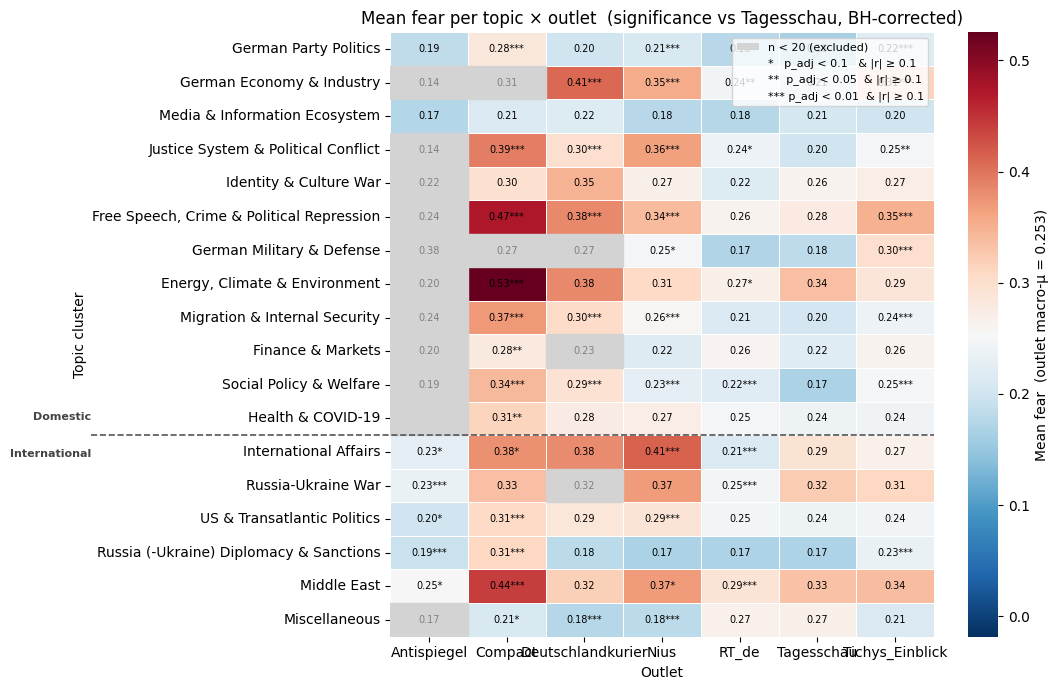

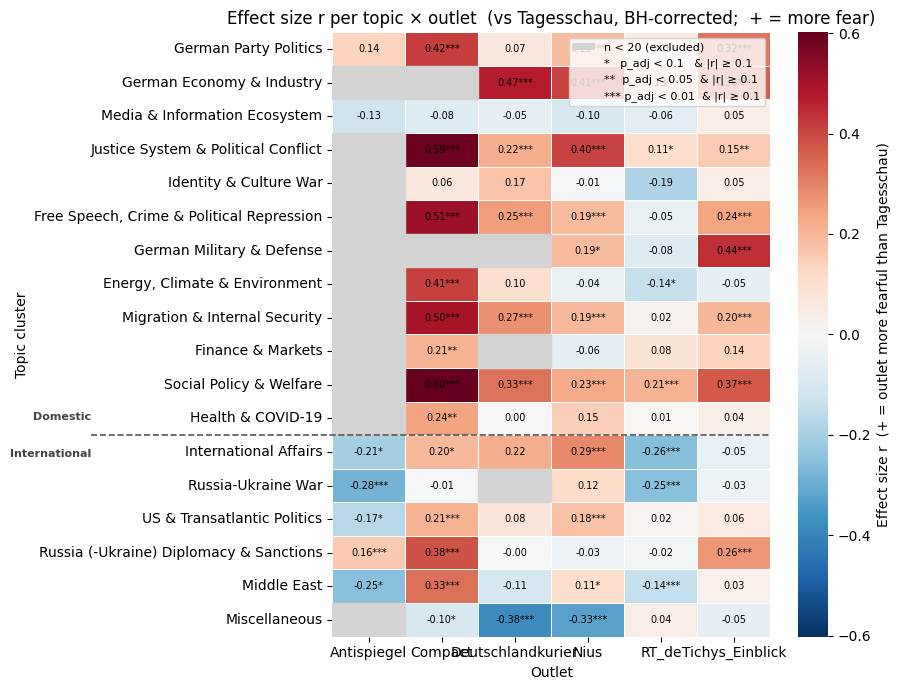

In [15]:
# topics already geo-sorted from anger cell above

FEAR_COL    = "fear"
macro_mean_fear = float(df.groupby("source")[FEAR_COL].mean().mean())

mean_pivot_f = (
    df.groupby(["topic", "source"])[FEAR_COL]
    .mean()
    .unstack("source")
    .reindex(index=topics, columns=all_outlets)
)

sig_lookup_f = (
    results_fear
    .set_index(["topic", "outlet"])["p_adj_masked"]
    .to_dict()
)

n_pivot_f = (
    df.groupby(["topic", "source"])[FEAR_COL]
    .count()
    .unstack("source")
    .reindex(index=topics, columns=all_outlets)
    .fillna(0)
)
ts_n_f = n_pivot_f.get(REFERENCE, pd.Series(0, index=topics))

grey_mask_f = pd.DataFrame(False, index=topics, columns=all_outlets)
for col in all_outlets:
    if col == REFERENCE:
        grey_mask_f[col] = n_pivot_f[col] < MIN_N
    else:
        grey_mask_f[col] = (n_pivot_f[col] < MIN_N) | (ts_n_f < MIN_N)

vals_f   = mean_pivot_f.to_numpy(dtype=float)
spread_f = max(float(np.nanmax(np.abs(vals_f - macro_mean_fear))), 1e-6)
vmin_f, vmax_f = macro_mean_fear - spread_f, macro_mean_fear + spread_f

# ── Heatmap 1: mean fear ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(12, 0.9 * len(all_outlets)),
                                max(7,  0.38 * len(topics))))

sns.heatmap(mean_pivot_f, ax=ax, annot=False,
            cmap="RdBu_r", center=macro_mean_fear, vmin=vmin_f, vmax=vmax_f,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": f"Mean fear  (outlet macro-μ = {macro_mean_fear:.3f})"})

for ri, topic in enumerate(topics):
    for ci, outlet in enumerate(all_outlets):
        val    = mean_pivot_f.at[topic, outlet]
        marker = _sig_marker(sig_lookup_f.get((topic, outlet), 1.0)) if outlet != REFERENCE else ""
        if grey_mask_f.at[topic, outlet]:
            ax.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
            if not np.isnan(val):
                ax.text(ci+0.5, ri+0.5, f"{val:.2f}", ha="center", va="center",
                        fontsize=7, color="grey", zorder=3)
        else:
            ax.text(ci+0.5, ri+0.5, f"{val:.2f}{marker}" if not np.isnan(val) else "",
                    ha="center", va="center", fontsize=7, color="black", zorder=3)

ax.legend(handles=legend_patches, loc="upper right", fontsize=8, frameon=True)
ax.set_title("Mean fear per topic × outlet  (significance vs Tagesschau, BH-corrected)")
ax.set_xlabel("Outlet")
ax.set_ylabel("Topic cluster")
_add_geo_brackets(ax, topics)
plt.tight_layout()
plt.show()

# ── Heatmap 2: effect size r ──────────────────────────────────────────────────
r_pivot_f   = results_fear.set_index(["topic", "outlet"])["effect_size_r"].unstack("outlet")
r_pivot_f   = r_pivot_f.reindex(index=[t for t in topics if t in r_pivot_f.index])
r_topics_f  = r_pivot_f.index.tolist()
r_outlets_f = r_pivot_f.columns.tolist()

grey_r_f = pd.DataFrame(False, index=r_topics_f, columns=r_outlets_f)
for rec in excluded_fear:
    t, o = rec["topic"], rec["outlet"]
    if t in grey_r_f.index and o in grey_r_f.columns:
        grey_r_f.at[t, o] = True

r_spread_f = max(float(np.nanmax(np.abs(r_pivot_f.to_numpy(dtype=float)))), 1e-6)

fig2, ax2 = plt.subplots(figsize=(max(10, 0.9 * len(r_outlets_f)),
                                  max(7,  0.38 * len(r_topics_f))))

sns.heatmap(r_pivot_f, ax=ax2, annot=False,
            cmap="RdBu_r", center=0, vmin=-r_spread_f, vmax=r_spread_f,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Effect size r  (+ = outlet more fearful than Tagesschau)"})

for ri, topic in enumerate(r_topics_f):
    for ci, outlet in enumerate(r_outlets_f):
        val    = r_pivot_f.at[topic, outlet] if topic in r_pivot_f.index else float("nan")
        marker = _sig_marker(sig_lookup_f.get((topic, outlet), 1.0))
        grey   = grey_r_f.at[topic, outlet] if topic in grey_r_f.index else True
        if grey:
            ax2.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
            if not np.isnan(val):
                ax2.text(ci+0.5, ri+0.5, f"{val:.2f}", ha="center", va="center",
                         fontsize=7, color="grey", zorder=3)
        else:
            ax2.text(ci+0.5, ri+0.5, f"{val:.2f}{marker}" if not np.isnan(val) else "",
                     ha="center", va="center", fontsize=7, color="black", zorder=3)

ax2.legend(handles=legend_patches, loc="upper right", fontsize=8, frameon=True)
ax2.set_title("Effect size r per topic × outlet  (vs Tagesschau, BH-corrected;  + = more fear)")
ax2.set_xlabel("Outlet")
ax2.set_ylabel("Topic cluster")
_add_geo_brackets(ax2, r_topics_f)
plt.tight_layout()
plt.show()
